# Phase 6-U — Event-Centered Temporal Observation

Phase 6 asked whether one final black-hole image can reveal past physical events.

Phase 6-T tested a short late-time temporal clip, but the clip only covered the last frames before the final observation. That means old events were not actually observed; the model mostly saw a relaxed state repeated over time.

Phase 6-U changes the observation strategy:

> Instead of observing only the final frames, the model observes a short temporal window centered on the injected event.

This tests a different scientific question:

> How much more recoverable are event identity and event timing when the observer samples the event itself?

The model receives:

```text
[B, T_clip, 1, H, W]
```

and predicts:

```text
event_type, event_age
```

This notebook reuses the existing Phase 6 histories and metadata, then generates event-centered simulator-style clips.

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import math
import random
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True


device(type='cuda')

In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

GPU_SIMULATOR_PATH = PROJECT_ROOT / "physics_blackhole_demo.py"

# Existing Phase 6 single-frame dataset. Phase 6-U reuses its histories and metadata.
PHASE6_DATASET_DIR = DATA_ROOT / "dataset_phase6_memory_persistence"

# New Phase 6-U event-centered temporal dataset.
DATASET_DIR = DATA_ROOT / "dataset_phase6U_event_centered_temporal_observation"
PHASE6U_DIR = OUTPUT_DIR / "phase6U_event_centered_temporal_observation"
PHASE6_DIR = OUTPUT_DIR / "phase6_memory_persistence"
PHASE6T_DIR = OUTPUT_DIR / "phase6T_temporal_memory_persistence"

# Set True only when intentionally regenerating event-centered clips.
OVERWRITE_DATASET = True

SEED = 42
IMAGE_SIZE = 128
HISTORY_T = 160

# Event-centered observation window.
# CLIP_LENGTH=16 captures several frames before and after the event.
CLIP_LENGTH = 8
CLIP_STRIDE = 1

# If True, the clip is centered exactly on event_center.
# If False, you can later test observer offsets.
CENTER_ON_EVENT = True

EVENT_AGES = [0, 5, 10, 20, 40, 60, 90, 120]
EVENT_TYPES = ["accretion_burst", "jet_eruption", "turbulence_spike", "spin_transition"]
EVENT_TO_INDEX = {name: i for i, name in enumerate(EVENT_TYPES)}
INDEX_TO_EVENT = {i: name for name, i in EVENT_TO_INDEX.items()}

TARGET_COLUMNS = ["mass", "spin", "accretion", "jet_power", "turbulence", "disk_luminosity"]

INPUT_MODE = "clean"  # options: "clean", "noisy"

BATCH_SIZE = 4
NUM_WORKERS = 0
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
NUM_EPOCHS = 45
LEARNING_RATE = 5e-4
EARLY_STOPPING_PATIENCE = 8

TYPE_LOSS_WEIGHT = 1.0
AGE_LOSS_WEIGHT = 0.75

NOISE_SIGMA_RANGE = (0.015, 0.11)
BLUR_SIGMA_RANGE = (0.0, 1.4)

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PHASE6U_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility controls.
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.use_deterministic_algorithms(True)
    DETERMINISTIC_ALGORITHMS = True
except Exception as e:
    DETERMINISTIC_ALGORITHMS = False
    print("Warning: deterministic algorithms could not be fully enabled.")
    print(e)

SPLIT_GENERATOR = torch.Generator().manual_seed(SEED)
LOADER_GENERATOR = torch.Generator().manual_seed(SEED)

print("Project root:", PROJECT_ROOT.resolve())
print("GPU simulator:", GPU_SIMULATOR_PATH.resolve())
print("GPU simulator exists:", GPU_SIMULATOR_PATH.exists())
print("Phase 6 source dataset:", PHASE6_DATASET_DIR.resolve())
print("Phase 6-U dataset:", DATASET_DIR.resolve())
print("Phase 6-U outputs:", PHASE6U_DIR.resolve())
print("Input mode:", INPUT_MODE)
print("Clip length:", CLIP_LENGTH)
print("Clip stride:", CLIP_STRIDE)
print("Center on event:", CENTER_ON_EVENT)
print("Deterministic algorithms:", DETERMINISTIC_ALGORITHMS)

import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

gc.collect()

Project root: /home/marwa/files/phase1_blackhole_generator
GPU simulator: /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py
GPU simulator exists: True
Phase 6 source dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence
Phase 6-U dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6U_event_centered_temporal_observation
Phase 6-U outputs: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation
Input mode: clean
Clip length: 8
Clip stride: 1
Center on event: True
Deterministic algorithms: True


92

In [3]:
# ================================================================
# 3. Verify Phase 6 source dataset and simulator
# ================================================================

if not GPU_SIMULATOR_PATH.exists():
    raise FileNotFoundError(
        f"Missing GPU simulator: {GPU_SIMULATOR_PATH}. Put physics_blackhole_demo.py in PROJECT_ROOT."
    )

if not PHASE6_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Missing Phase 6 dataset: {PHASE6_DATASET_DIR}. Run Phase 6 first."
    )

for required in ["params_table.csv", "manifest.json"]:
    path = PHASE6_DATASET_DIR / required
    if not path.exists():
        raise FileNotFoundError(f"Missing required Phase 6 file: {path}")

for sd in ["clean", "noisy", "history", "metadata"]:
    path = PHASE6_DATASET_DIR / sd
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 6 subfolder: {path}")

sim_source = GPU_SIMULATOR_PATH.read_bytes()
simulator_sha256 = hashlib.sha256(sim_source).hexdigest()
sim_text = sim_source.decode("utf-8", errors="ignore")

print("Simulator SHA256:", simulator_sha256)
for token in ["u_mass", "u_spin", "u_accretion", "u_time"]:
    print(f"contains {token}:", token in sim_text)

with open(PHASE6_DATASET_DIR / "manifest.json", "r") as f:
    phase6_manifest = json.load(f)

params_df = pd.read_csv(PHASE6_DATASET_DIR / "params_table.csv")

print("Phase 6 samples:", len(params_df))
print("Phase 6 event types:", phase6_manifest.get("event_types"))
print("Phase 6 event ages:", phase6_manifest.get("event_ages"))
display(params_df.head())

Simulator SHA256: 41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a
contains u_mass: True
contains u_spin: True
contains u_accretion: True
contains u_time: True
Phase 6 samples: 1120
Phase 6 event types: ['accretion_burst', 'jet_eruption', 'turbulence_spike', 'spin_transition']
Phase 6 event ages: [0, 5, 10, 20, 40, 60, 90, 120]


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,jet_power,turbulence,disk_luminosity,event_profile_recent,event_age,event_center,sample_id,sample_index,event_type,event_type_index
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,0.368827,0.270658,0.710300,0.294393,0,159,p6_00001,1,accretion_burst,0
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,0.560022,0.191374,0.835475,0.301307,0,159,p6_00002,2,accretion_burst,0
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,0.397768,0.601976,0.665426,0.365520,0,159,p6_00003,3,accretion_burst,0
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,0.421727,0.326509,1.326374,0.307380,0,159,p6_00004,4,accretion_burst,0
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,0.703728,0.392102,1.198455,0.490090,0,159,p6_00005,5,accretion_burst,0


In [4]:
# ================================================================
# 4. Recreate Phase 6 simulator-compatible renderer
# ================================================================

_RENDER_CACHE = {}


def get_grid(size, device):
    key = (size, str(device))
    if key in _RENDER_CACHE:
        return _RENDER_CACHE[key]
    axis = torch.linspace(-1.0, 1.0, size, device=device)
    y, x = torch.meshgrid(axis, axis, indexing="ij")
    r = torch.sqrt(x * x + y * y + 1e-8)
    phi = torch.atan2(y, x)
    _RENDER_CACHE[key] = (x, y, r, phi)
    return x, y, r, phi


def summary_at_frame(history_df, frame_index, window=18):
    frame_index = int(frame_index)
    start = max(0, frame_index - window + 1)
    recent = history_df.iloc[start:frame_index + 1]
    current = history_df.iloc[frame_index]

    return {
        "mass": float(current["mass"]),
        "spin": float(recent["spin"].mean()),
        "spin_final": float(current["spin"]),
        "accretion": float(recent["accretion"].mean()),
        "jet_power": float(recent["jet_power"].mean()),
        "turbulence": float(recent["turbulence"].mean()),
        "disk_luminosity": float(recent["disk_luminosity"].mean()),
        "event_profile_recent": float(recent["event_profile"].mean()),
        "event_age": float(current["event_age"]),
        "event_center": float(current["event_center"]),
        "frame_index": frame_index,
    }


def render_simulator_frame_at(params_row, history_df, frame_index, size=128, device=DEVICE):
    h = summary_at_frame(history_df, frame_index)
    x, y, r, phi = get_grid(size, device)

    mass = torch.tensor(h["mass"], device=device)
    spin = torch.tensor(h["spin"], device=device)
    spin_final = torch.tensor(h["spin_final"], device=device)
    acc = torch.tensor(h["accretion"], device=device)
    jet_power = torch.tensor(h["jet_power"], device=device)
    turb_level = torch.tensor(h["turbulence"], device=device)
    lum = torch.tensor(h["disk_luminosity"], device=device)
    event_recent = torch.tensor(h["event_profile_recent"], device=device)

    observer_angle = torch.tensor(float(params_row["observer_angle"]) * math.pi / 180.0, device=device)
    yaw = torch.tensor(float(params_row["camera_yaw"]), device=device)

    cos_i = torch.clamp(torch.cos(observer_angle), min=0.30)
    x_cam = x * torch.cos(yaw) - y * torch.sin(yaw)
    y_cam = x * torch.sin(yaw) + y * torch.cos(yaw)
    y_inc = y_cam / cos_i

    spin_shift = 0.035 * (spin_final - 0.5)
    x_shift = x_cam - spin_shift
    r_inc = torch.sqrt(x_shift * x_shift + y_inc * y_inc + 1e-8)
    phi_inc = torch.atan2(y_inc, x_shift)

    shadow_radius = 0.095 + 0.010 * (mass / 10.0)
    shadow_edge = 0.014 + 0.006 * jet_power
    shadow_mask = torch.clamp((r - shadow_radius) / shadow_edge, 0.0, 1.0)

    warp = 0.018 * spin * torch.sin(phi_inc - spin * math.pi)
    warp += 0.012 * turb_level * torch.sin(3.0 * phi_inc + spin * 2.0 * math.pi)
    ring_radius = 0.175 + 0.012 * (mass / 10.0 - 1.0) + warp
    ring_width = 0.025 + 0.010 * jet_power
    ring = torch.exp(-0.5 * ((r_inc - ring_radius) / ring_width) ** 2)
    ring *= 1.0 + (0.40 + 0.55 * spin) * torch.sin(observer_angle) * torch.cos(phi_inc - spin * math.pi)

    inner = 0.16 + 0.010 * (mass / 10.0 - 1.0)
    outer = 0.76 + 0.08 * lum
    disk_mask = torch.sigmoid((r_inc - inner) / 0.018) * torch.sigmoid((outer - r_inc) / 0.04)
    radial = torch.exp(-2.6 * torch.clamp((r_inc - inner) / (outer - inner + 1e-6), 0.0, 2.0))
    disk = disk_mask * radial * (0.45 + 0.65 * lum) * (0.55 + 0.45 * acc)

    texture = torch.zeros_like(r)
    for k in range(1, 9):
        phase = 0.8 * k + 0.13 * h["event_center"] + 0.07 * frame_index
        texture += torch.sin((2.0 + k * 1.7) * phi_inc + phase) * torch.cos((3.0 + k * 0.85) * r_inc * math.pi + phase)
    texture = texture / 8.0
    disk = disk * (1.0 + (0.20 + 0.35 * turb_level) * texture)

    clumps = torch.zeros_like(r)
    for k in range(4):
        angle = 1.3 * k + 0.07 * h["event_center"] + 0.05 * frame_index + float(spin.detach().cpu())
        rr = 0.25 + 0.09 * k
        dphi = torch.atan2(torch.sin(phi_inc - angle), torch.cos(phi_inc - angle))
        clumps += torch.exp(-0.5 * ((r_inc - rr) / 0.045) ** 2) * torch.exp(-0.5 * (dphi / 0.23) ** 2)
    disk = disk + 0.22 * torch.clamp(0.30 * turb_level + 0.75 * event_recent, 0.0, 1.4) * clumps * disk_mask

    tilt = (spin - 0.5) * 0.40 + yaw * 0.25
    x_rot = x * torch.cos(tilt) - y * torch.sin(tilt)
    y_rot = x * torch.sin(tilt) + y * torch.cos(tilt)
    jet_width = 0.035 + 0.035 * torch.clamp(jet_power, 0.0, 1.5)
    jet_len = 0.42 + 0.26 * torch.clamp(jet_power, 0.0, 1.5)
    upper = torch.exp(-0.5 * (x_rot / jet_width) ** 2) * torch.exp(-torch.clamp(y_rot, min=0.0) / jet_len) * (y_rot > 0.14).float()
    lower = torch.exp(-0.5 * (x_rot / (jet_width * 1.15)) ** 2) * torch.exp(-torch.clamp(-y_rot, min=0.0) / (jet_len * 0.9)) * (y_rot < -0.14).float()
    jet = (upper + 0.75 * lower) * (0.15 + 0.75 * jet_power) * (0.35 + 0.65 * torch.sin(observer_angle))

    glow = torch.exp(-((r_inc / (0.55 + 0.12 * lum)) ** 2)) * (0.06 + 0.16 * lum)
    image = (0.74 * disk + 0.92 * ring + 0.55 * jet + glow) * shadow_mask
    image = torch.clamp(image, min=0.0)
    image = image / (image.max() + 1e-6)
    return torch.clamp(image, 0.0, 1.0).detach().float().cpu().numpy()


def gaussian_blur_numpy(image, sigma):
    if sigma <= 1e-8:
        return image.astype(np.float32)
    radius = int(max(1, round(3 * sigma)))
    xs = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (xs / sigma) ** 2)
    kernel = kernel / kernel.sum()
    temp = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 0, image)
    out = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 1, temp)
    return out.astype(np.float32)


def corrupt_frame(clean, noise_sigma, blur_sigma, rng):
    image = gaussian_blur_numpy(clean.astype(np.float32), float(blur_sigma))
    image += rng.normal(0.0, float(noise_sigma), image.shape).astype(np.float32)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def save_npz_clip(arr, path):
    arr = np.asarray(arr, dtype=np.float32)
    np.savez_compressed(path, clip=arr)


def load_npz_clip(path):
    with np.load(path) as data:
        return data["clip"].astype(np.float32)

In [5]:
# ================================================================
# 5. Prepare Phase 6-U output folders
# ================================================================

subdirs = ["clips_clean", "clips_noisy", "metadata", "history"]

existing_files = []
if DATASET_DIR.exists():
    existing_files = [p for p in DATASET_DIR.glob("**/*") if p.is_file()]

if existing_files:
    print(f"Existing Phase 6-U dataset detected with {len(existing_files)} files.")
    if OVERWRITE_DATASET:
        print("OVERWRITE_DATASET=True: removing old Phase 6-U dataset.")
        shutil.rmtree(DATASET_DIR)
    else:
        print("OVERWRITE_DATASET=False: keeping existing Phase 6-U dataset.")

for sd in subdirs:
    (DATASET_DIR / sd).mkdir(parents=True, exist_ok=True)

print("Phase 6-U folders ready:")
for sd in subdirs:
    print(sd, len(list((DATASET_DIR / sd).glob("*"))))

Existing Phase 6-U dataset detected with 4482 files.
OVERWRITE_DATASET=True: removing old Phase 6-U dataset.
Phase 6-U folders ready:
clips_clean 0
clips_noisy 0
metadata 0
history 0


In [6]:
# ================================================================
# 6. Generate event-centered temporal clip dataset
# ================================================================


def event_centered_frame_indices(event_center, clip_length, stride, history_T):
    event_center = int(event_center)
    half_before = (clip_length - 1) // 2
    start = event_center - half_before * stride
    frames = [start + k * stride for k in range(clip_length)]

    # Shift the window if it falls outside the valid history range.
    if frames[0] < 0:
        shift = -frames[0]
        frames = [f + shift for f in frames]
    if frames[-1] > history_T - 1:
        shift = frames[-1] - (history_T - 1)
        frames = [f - shift for f in frames]

    frames = [int(max(0, min(history_T - 1, f))) for f in frames]
    return frames


rows = []

if (DATASET_DIR / "params_table.csv").exists() and not OVERWRITE_DATASET:
    print("Loading existing Phase 6-U params table.")
    phase6u_params_df = pd.read_csv(DATASET_DIR / "params_table.csv")
else:
    for idx, row in params_df.iterrows():
        sample_id = str(row["sample_id"])
        history_path = PHASE6_DATASET_DIR / "history" / f"{sample_id}.csv"
        history_df = pd.read_csv(history_path)

        event_center = int(row["event_center"])
        frame_indices = event_centered_frame_indices(
            event_center=event_center,
            clip_length=CLIP_LENGTH,
            stride=CLIP_STRIDE,
            history_T=HISTORY_T,
        )

        clean_frames = []
        noisy_frames = []
        rng = np.random.default_rng(SEED + int(row["sample_index"]) * 41)

        for frame_idx in frame_indices:
            clean = render_simulator_frame_at(row, history_df, frame_idx, IMAGE_SIZE, DEVICE)
            noisy = corrupt_frame(clean, row["noise_sigma"], row["blur_sigma"], rng)
            clean_frames.append(clean)
            noisy_frames.append(noisy)

        clean_clip = np.stack(clean_frames, axis=0).astype(np.float32)  # [T,H,W]
        noisy_clip = np.stack(noisy_frames, axis=0).astype(np.float32)

        save_npz_clip(clean_clip, DATASET_DIR / "clips_clean" / f"{sample_id}.npz")
        save_npz_clip(noisy_clip, DATASET_DIR / "clips_noisy" / f"{sample_id}_noisy.npz")
        history_df.to_csv(DATASET_DIR / "history" / f"{sample_id}.csv", index=False)

        metadata = {
            "sample_id": sample_id,
            "source_phase6_dataset": str(PHASE6_DATASET_DIR),
            "event_type": row["event_type"],
            "event_type_index": int(row["event_type_index"]),
            "event_age": float(row["event_age"]),
            "event_center": int(row["event_center"]),
            "clip_length": CLIP_LENGTH,
            "clip_stride": CLIP_STRIDE,
            "center_on_event": CENTER_ON_EVENT,
            "frame_indices": frame_indices,
            "frame_start": frame_indices[0],
            "frame_end": frame_indices[-1],
            "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
            "gpu_simulator_sha256": simulator_sha256,
        }

        with open(DATASET_DIR / "metadata" / f"{sample_id}.json", "w") as f:
            json.dump(metadata, f, indent=2)

        out_row = row.to_dict()
        out_row.update({
            "clip_length": CLIP_LENGTH,
            "clip_stride": CLIP_STRIDE,
            "center_on_event": CENTER_ON_EVENT,
            "frame_start": frame_indices[0],
            "frame_end": frame_indices[-1],
            "clip_contains_event_center": int(event_center in frame_indices),
        })
        rows.append(out_row)

        if (idx + 1) % 100 == 0:
            print(f"Generated event-centered clips {idx + 1}/{len(params_df)}")

    phase6u_params_df = pd.DataFrame(rows)
    phase6u_params_df.to_csv(DATASET_DIR / "params_table.csv", index=False)

print("Phase 6-U samples:", len(phase6u_params_df))
print("Clip contains event center:", phase6u_params_df["clip_contains_event_center"].mean())
display(phase6u_params_df.head())

Generated event-centered clips 100/1120
Generated event-centered clips 200/1120
Generated event-centered clips 300/1120
Generated event-centered clips 400/1120
Generated event-centered clips 500/1120
Generated event-centered clips 600/1120
Generated event-centered clips 700/1120
Generated event-centered clips 800/1120
Generated event-centered clips 900/1120
Generated event-centered clips 1000/1120
Generated event-centered clips 1100/1120
Phase 6-U samples: 1120
Clip contains event center: 1.0


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,sample_id,sample_index,event_type,event_type_index,clip_length,clip_stride,center_on_event,frame_start,frame_end,clip_contains_event_center
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,p6_00001,1,accretion_burst,0,8,1,True,152,159,1
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,p6_00002,2,accretion_burst,0,8,1,True,152,159,1
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,p6_00003,3,accretion_burst,0,8,1,True,152,159,1
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,p6_00004,4,accretion_burst,0,8,1,True,152,159,1
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,p6_00005,5,accretion_burst,0,8,1,True,152,159,1


In [7]:
# ================================================================
# 7. Manifest and integrity checks
# ================================================================

manifest = {
    "dataset_name": "phase6U_event_centered_temporal_observation_dataset",
    "version": "6U.0",
    "n_samples": int(len(phase6u_params_df)),
    "image_size": IMAGE_SIZE,
    "history_T": HISTORY_T,
    "clip_length": CLIP_LENGTH,
    "clip_stride": CLIP_STRIDE,
    "center_on_event": CENTER_ON_EVENT,
    "input_modes": ["clean", "noisy"],
    "seed": SEED,
    "event_types": EVENT_TYPES,
    "event_ages": EVENT_AGES,
    "source_phase6_dataset": str(PHASE6_DATASET_DIR),
    "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
    "gpu_simulator_sha256": simulator_sha256,
    "scientific_question": "How much more memory is recoverable when the observation window contains the event itself?",
}

with open(DATASET_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

for sd in ["clips_clean", "clips_noisy", "metadata", "history"]:
    files = list((DATASET_DIR / sd).glob("*"))
    print(sd, len(files))
    assert len(files) == len(phase6u_params_df), f"Unexpected file count in {sd}"

example_sid = str(phase6u_params_df.iloc[0]["sample_id"])
example_clip = load_npz_clip(DATASET_DIR / "clips_clean" / f"{example_sid}.npz")
assert example_clip.shape == (CLIP_LENGTH, IMAGE_SIZE, IMAGE_SIZE), example_clip.shape

assert phase6u_params_df["clip_contains_event_center"].mean() > 0.99

print("Integrity checks passed.")
print("Example clip shape:", example_clip.shape)

clips_clean 1120
clips_noisy 1120
metadata 1120
history 1120
Integrity checks passed.
Example clip shape: (8, 128, 128)


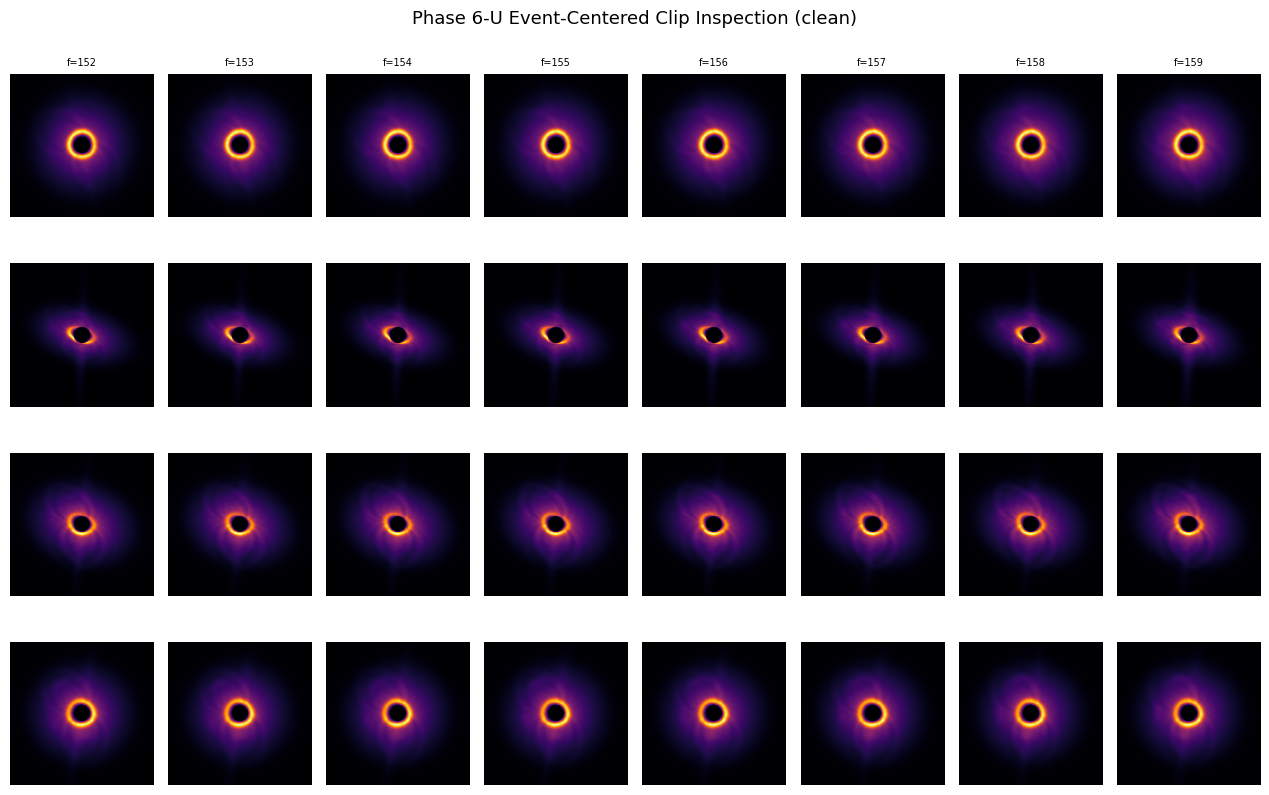

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_clip_visual_inspection_clean_clip8.png


In [8]:
# ================================================================
# 8. Visual inspection of event-centered temporal clips
# ================================================================

inspect_cases = []
for event_type in EVENT_TYPES:
    sub = phase6u_params_df[phase6u_params_df["event_type"] == event_type]
    inspect_cases.append(sub.iloc[0])

fig, axes = plt.subplots(len(inspect_cases), CLIP_LENGTH, figsize=(1.6 * CLIP_LENGTH, 2.1 * len(inspect_cases)))
if len(inspect_cases) == 1:
    axes = np.array([axes])

for row_idx, row in enumerate(inspect_cases):
    sid = str(row["sample_id"])
    clip_path = DATASET_DIR / ("clips_clean" if INPUT_MODE == "clean" else "clips_noisy") / (f"{sid}.npz" if INPUT_MODE == "clean" else f"{sid}_noisy.npz")
    clip = load_npz_clip(clip_path)
    event_center = int(row["event_center"])
    frame_start = int(row["frame_start"])

    for t in range(CLIP_LENGTH):
        ax = axes[row_idx, t]
        ax.imshow(clip[t], cmap="inferno", vmin=0, vmax=1)
        ax.axis("off")
        frame_idx = frame_start + t * CLIP_STRIDE
        if t == 0:
            ax.set_ylabel(f"{row['event_type']}\nage={row['event_age']}", fontsize=8)
        if row_idx == 0:
            ax.set_title(f"f={frame_idx}", fontsize=7)
        if frame_idx == event_center:
            ax.set_xlabel("event", fontsize=7)

plt.suptitle(f"Phase 6-U Event-Centered Clip Inspection ({INPUT_MODE})", fontsize=13)
plt.tight_layout()
inspection_path = PHASE6U_DIR / f"phase6U_clip_visual_inspection_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(inspection_path, dpi=150)
plt.show()

print("Saved:", inspection_path)

In [9]:
# ================================================================
# 9. Dataset class and loaders
# ================================================================

class Phase6UEventCenteredDataset(Dataset):
    def __init__(self, dataset_dir, input_mode="clean"):
        self.dataset_dir = Path(dataset_dir)
        self.input_mode = str(input_mode).lower().strip()
        self.params = pd.read_csv(self.dataset_dir / "params_table.csv")
        self.clean_dir = self.dataset_dir / "clips_clean"
        self.noisy_dir = self.dataset_dir / "clips_noisy"

        if self.input_mode not in ["clean", "noisy"]:
            raise ValueError(f"input_mode must be 'clean' or 'noisy', got {input_mode}")

    def __len__(self):
        return len(self.params)

    def _clip_path(self, sample_id):
        if self.input_mode == "clean":
            return self.clean_dir / f"{sample_id}.npz"
        return self.noisy_dir / f"{sample_id}_noisy.npz"

    def __getitem__(self, idx):
        row = self.params.iloc[idx]
        sample_id = str(row["sample_id"])
        clip = load_npz_clip(self._clip_path(sample_id))  # [T,H,W]
        clip = torch.from_numpy(clip).unsqueeze(1)         # [T,1,H,W]
        event_type = torch.tensor(int(row["event_type_index"]), dtype=torch.long)
        event_age = torch.tensor([float(row["event_age"]) / max(EVENT_AGES)], dtype=torch.float32)
        return clip, event_type, event_age, sample_id


temporal_dataset = Phase6UEventCenteredDataset(DATASET_DIR, input_mode=INPUT_MODE)

n_total = len(temporal_dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    temporal_dataset,
    [n_train, n_val, n_test],
    generator=SPLIT_GENERATOR,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=LOADER_GENERATOR,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

clip, event_type, event_age, sid = temporal_dataset[0]
print("Dataset size:", len(temporal_dataset))
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
print("Example sample:", sid)
print("Clip shape:", clip.shape)
print("Event type:", event_type.item(), INDEX_TO_EVENT[event_type.item()])
print("Event age normalized:", event_age.item())

Dataset size: 1120
Train: 896 Val: 112 Test: 112
Example sample: p6_00001
Clip shape: torch.Size([8, 1, 128, 128])
Event type: 0 accretion_burst
Event age normalized: 0.0


In [10]:
# ================================================================
# 10. Temporal memory model: CNN frame encoder + GRU
# ================================================================

class FrameEncoder(nn.Module):
    def __init__(self, base=16, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base, 3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.SiLU(inplace=True),
            nn.Conv2d(base, base, 3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base, base * 2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 2),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base * 2, base * 4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 4),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base * 4, base * 8, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 8),
            nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(base * 8, latent_dim),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Phase6UEventCenteredMemoryNet(nn.Module):
    def __init__(self, num_events=4, latent_dim=128, hidden_dim=128, dropout=0.20):
        super().__init__()
        self.encoder = FrameEncoder(base=32, latent_dim=latent_dim)
        self.gru = nn.GRU(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.temporal_attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.type_head = nn.Linear(hidden_dim, num_events)
        self.age_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, clip):
        # clip: [B,T,1,H,W]
        B, T, C, H, W = clip.shape
        frames = clip.view(B * T, C, H, W)
        z = self.encoder(frames)
        z = z.view(B, T, -1)
        out, _ = self.gru(z)
        weights = torch.softmax(self.temporal_attention(out), dim=1)
        pooled = (weights * out).sum(dim=1)
        h = self.head(pooled)
        return self.type_head(h), self.age_head(h)


model = Phase6UEventCenteredMemoryNet(
    num_events=len(EVENT_TYPES),
    latent_dim=128,
    hidden_dim=128,
).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 695,206


In [11]:
# ================================================================
# 11. Training utilities
# ================================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)


def compute_loss(logits, pred_age, true_type, true_age):
    type_loss = F.cross_entropy(logits, true_type)
    age_loss = F.smooth_l1_loss(pred_age, true_age)
    loss = TYPE_LOSS_WEIGHT * type_loss + AGE_LOSS_WEIGHT * age_loss
    return loss, type_loss, age_loss


def r2_score_np(pred, true):
    pred = np.asarray(pred).reshape(-1)
    true = np.asarray(true).reshape(-1)
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2) + 1e-8
    return float(1.0 - ss_res / ss_tot)


def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for clip, event_type, event_age, _ in loader:
        clip = clip.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)

        logits, pred_age = model(clip)
        loss, _, _ = compute_loss(logits, pred_age, event_type, event_age)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * clip.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, type_losses, age_losses = [], [], []
    all_sids, true_types, pred_types, true_ages, pred_ages = [], [], [], [], []

    for clip, event_type, event_age, sample_ids in loader:
        clip = clip.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)

        logits, pred_age = model(clip)
        loss, type_loss, age_loss = compute_loss(logits, pred_age, event_type, event_age)
        pred_type = logits.argmax(dim=1)

        losses.append(loss.item())
        type_losses.append(type_loss.item())
        age_losses.append(age_loss.item())

        all_sids.extend(list(sample_ids))
        true_types.extend(event_type.cpu().numpy().tolist())
        pred_types.extend(pred_type.cpu().numpy().tolist())
        true_ages.extend((event_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())
        pred_ages.extend((pred_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())

    true_ages_np = np.array(true_ages)
    pred_ages_np = np.array(pred_ages)
    true_types_np = np.array(true_types)
    pred_types_np = np.array(pred_types)

    return {
        "loss": float(np.mean(losses)),
        "type_loss": float(np.mean(type_losses)),
        "age_loss": float(np.mean(age_losses)),
        "type_accuracy": float(np.mean(true_types_np == pred_types_np)),
        "age_mae": float(np.mean(np.abs(true_ages_np - pred_ages_np))),
        "age_r2": r2_score_np(pred_ages_np, true_ages_np),
        "sample_ids": all_sids,
        "true_type": true_types,
        "pred_type": pred_types,
        "true_age": true_ages,
        "pred_age": pred_ages,
    }

In [12]:
# ================================================================
# 12. Train event-centered temporal model
# ================================================================

best_val_loss = float("inf")
patience = 0
history = []

best_model_path = PHASE6U_DIR / f"best_phase6U_event_centered_model_{INPUT_MODE}_clip{CLIP_LENGTH}.pt"
history_path = PHASE6U_DIR / f"phase6U_training_history_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"

print("=" * 70)
print("Phase 6-U Training")
print("=" * 70)
print("Input mode:", INPUT_MODE)
print("Clip length:", CLIP_LENGTH)
print("Best model path:", best_model_path)
print("History path:", history_path)
print("=" * 70)
import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)
    scheduler.step(val_metrics["loss"])
    lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_loss": float(val_metrics["loss"]),
        "val_type_loss": float(val_metrics["type_loss"]),
        "val_age_loss": float(val_metrics["age_loss"]),
        "val_type_accuracy": float(val_metrics["type_accuracy"]),
        "val_age_mae": float(val_metrics["age_mae"]),
        "val_age_r2": float(val_metrics["age_r2"]),
        "lr": float(lr),
    }
    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = float(val_metrics["loss"])
        patience = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_loss": best_val_loss,
                "input_mode": INPUT_MODE,
                "clip_length": CLIP_LENGTH,
                "clip_stride": CLIP_STRIDE,
                "center_on_event": CENTER_ON_EVENT,
                "event_types": EVENT_TYPES,
                "event_ages": EVENT_AGES,
                "seed": SEED,
                "config": {
                    "batch_size": BATCH_SIZE,
                    "num_epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "type_loss_weight": TYPE_LOSS_WEIGHT,
                    "age_loss_weight": AGE_LOSS_WEIGHT,
                    "deterministic_algorithms": DETERMINISTIC_ALGORITHMS,
                },
            },
            best_model_path,
        )
        best_flag = " <-- best"
    else:
        patience += 1
        best_flag = ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"train={train_loss:.5f} | "
        f"val={val_metrics['loss']:.5f} | "
        f"acc={val_metrics['type_accuracy']:.3f} | "
        f"age_MAE={val_metrics['age_mae']:.2f} | "
        f"age_R2={val_metrics['age_r2']:.3f} | "
        f"lr={lr:.2e}{best_flag}"
    )

    if patience >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.5f}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
print("Saved:", best_model_path)

Phase 6-U Training
Input mode: clean
Clip length: 8
Best model path: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/best_phase6U_event_centered_model_clean_clip8.pt
History path: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_training_history_clean_clip8.csv
Epoch 001/45 | train=1.41256 | val=1.50169 | acc=0.330 | age_MAE=38.30 | age_R2=-0.020 | lr=5.00e-04 <-- best
Epoch 002/45 | train=1.37796 | val=1.34763 | acc=0.357 | age_MAE=37.08 | age_R2=-0.006 | lr=5.00e-04 <-- best
Epoch 003/45 | train=1.31756 | val=1.27532 | acc=0.375 | age_MAE=37.00 | age_R2=-0.003 | lr=5.00e-04 <-- best
Epoch 004/45 | train=1.05202 | val=0.92465 | acc=0.580 | age_MAE=36.88 | age_R2=-0.009 | lr=5.00e-04 <-- best
Epoch 005/45 | train=0.98543 | val=0.93169 | acc=0.509 | age_MAE=37.98 | age_R2=-0.006 | lr=5.00e-04
Epoch 006/45 | train=0.93049 | val=0.77446 | acc=0.634 | age_MAE=36.64 | age_R2=-0.009 | lr=

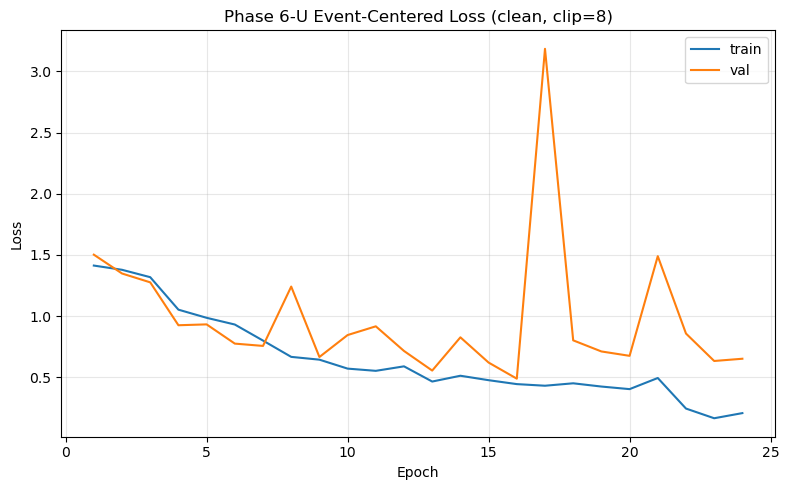

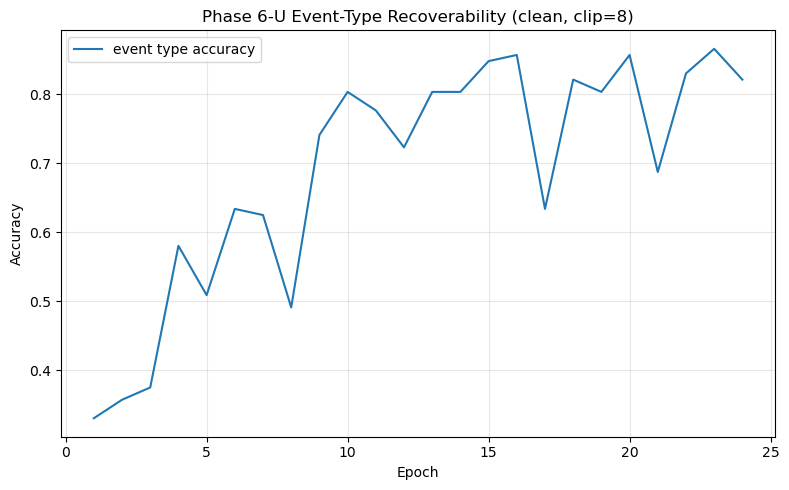

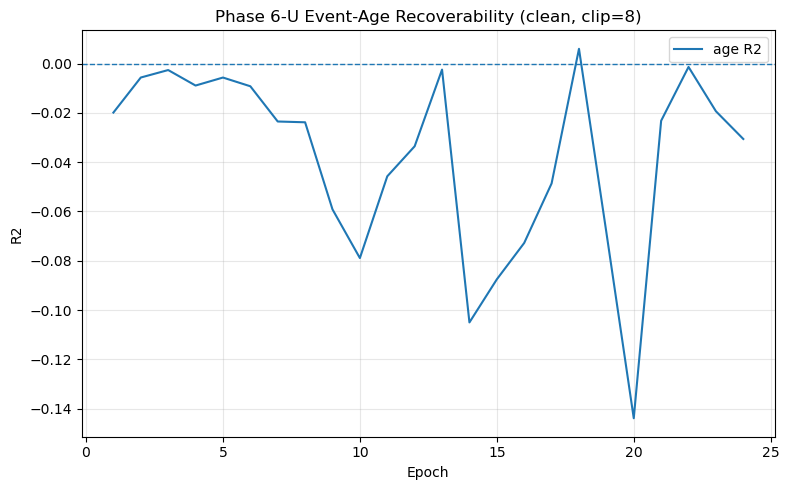

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_loss_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_type_accuracy_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_age_r2_curve_clean_clip8.png


In [13]:
# ================================================================
# 13. Training curves
# ================================================================

history_df = pd.DataFrame(history)
epochs = history_df["epoch"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_loss"].to_numpy(), label="train")
plt.plot(epochs, history_df["val_loss"].to_numpy(), label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Phase 6-U Event-Centered Loss ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
loss_plot_path = PHASE6U_DIR / f"phase6U_loss_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["val_type_accuracy"].to_numpy(), label="event type accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Phase 6-U Event-Type Recoverability ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
acc_plot_path = PHASE6U_DIR / f"phase6U_type_accuracy_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(acc_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["val_age_r2"].to_numpy(), label="age R2")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title(f"Phase 6-U Event-Age Recoverability ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
age_plot_path = PHASE6U_DIR / f"phase6U_age_r2_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(age_plot_path, dpi=150)
plt.show()

print("Saved:", loss_plot_path)
print("Saved:", acc_plot_path)
print("Saved:", age_plot_path)

In [14]:
# ================================================================
# 14. Test evaluation
# ================================================================

checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics = evaluate(model, test_loader)

print("Test loss:", test_metrics["loss"])
print("Type accuracy:", test_metrics["type_accuracy"])
print("Age MAE frames:", test_metrics["age_mae"])
print("Age R2:", test_metrics["age_r2"])

pred_df = pd.DataFrame({
    "sample_id": test_metrics["sample_ids"],
    "true_type_index": test_metrics["true_type"],
    "pred_type_index": test_metrics["pred_type"],
    "true_age": test_metrics["true_age"],
    "pred_age": test_metrics["pred_age"],
})

pred_df["true_event_type"] = pred_df["true_type_index"].map(INDEX_TO_EVENT)
pred_df["pred_event_type"] = pred_df["pred_type_index"].map(INDEX_TO_EVENT)
pred_df["correct_type"] = pred_df["true_type_index"] == pred_df["pred_type_index"]
pred_df["age_abs_error"] = np.abs(pred_df["true_age"] - pred_df["pred_age"])
pred_df = pred_df.merge(phase6u_params_df, on="sample_id", how="left")

pred_path = PHASE6U_DIR / f"phase6U_test_predictions_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
pred_df.to_csv(pred_path, index=False)

metrics_path = PHASE6U_DIR / f"phase6U_test_metrics_{INPUT_MODE}_clip{CLIP_LENGTH}.json"
with open(metrics_path, "w") as f:
    json.dump({k: v for k, v in test_metrics.items() if k not in ["sample_ids", "true_type", "pred_type", "true_age", "pred_age"]}, f, indent=2)

display(pred_df.head())
print("Saved:", pred_path)
print("Saved:", metrics_path)

Test loss: 0.5513661237699645
Type accuracy: 0.8392857142857143
Age MAE frames: 35.103918296950205
Age R2: -0.040181376130521196


,sample_id,true_type_index,pred_type_index,true_age,pred_age,true_event_type,pred_event_type,correct_type,age_abs_error,mass,...,event_center,sample_index,event_type,event_type_index,clip_length,clip_stride,center_on_event,frame_start,frame_end,clip_contains_event_center
0,p6_00745,2,2,60.0,30.878807,turbulence_spike,turbulence_spike,True,29.121193,8.836098,...,99,745,turbulence_spike,2,8,1,True,96,103,1
1,p6_00565,2,2,0.0,28.566504,turbulence_spike,turbulence_spike,True,28.566504,8.078439,...,159,565,turbulence_spike,2,8,1,True,152,159,1
2,p6_00400,1,1,20.0,32.022598,jet_eruption,jet_eruption,True,12.022598,13.769351,...,139,400,jet_eruption,1,8,1,True,136,143,1
3,p6_00592,2,2,0.0,32.083630,turbulence_spike,turbulence_spike,True,32.083630,9.473547,...,159,592,turbulence_spike,2,8,1,True,152,159,1
4,p6_00507,1,0,90.0,34.335045,jet_eruption,accretion_burst,False,55.664955,6.725646,...,69,507,jet_eruption,1,8,1,True,66,73,1


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_test_predictions_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_test_metrics_clean_clip8.json


,event_age,type_accuracy,age_mae,n
0,0.0,1.000000,32.864978,21
1,5.0,0.875000,28.312146,8
2,10.0,0.687500,24.872017,16
3,20.0,1.000000,12.253534,11
4,40.0,0.538462,5.732259,13
5,60.0,0.882353,25.691819,17
6,90.0,0.888889,56.819419,9
7,120.0,0.823529,85.857702,17


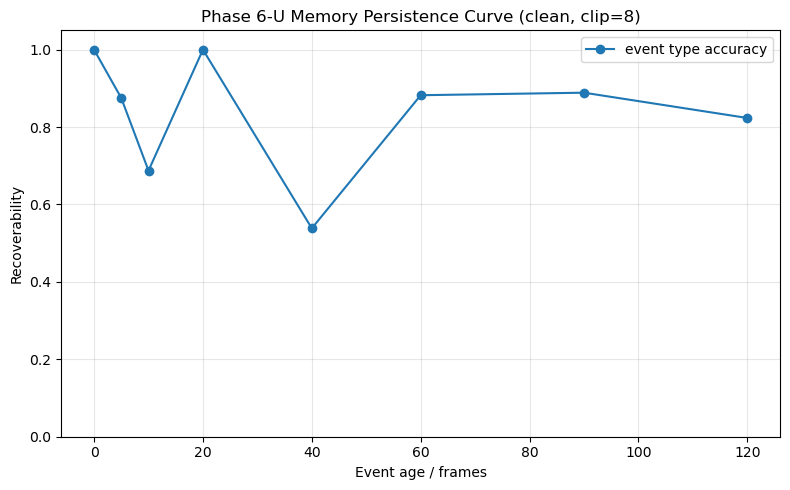

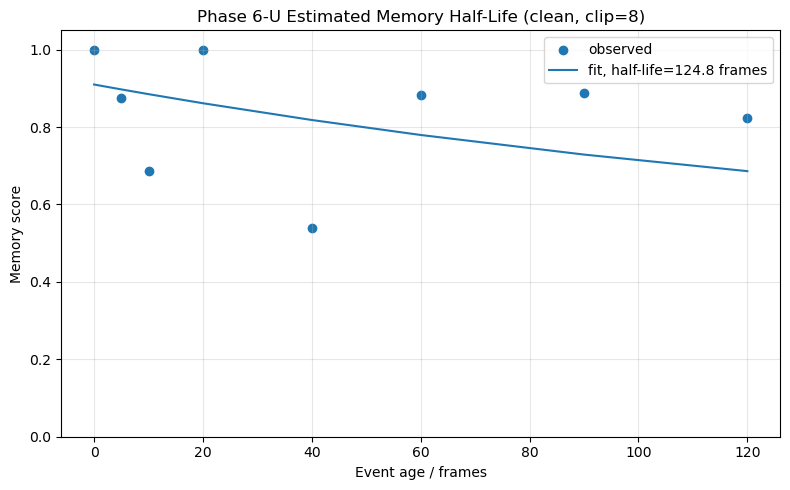

Memory half-life frames: 124.76649250079015
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_memory_curve_by_age_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_memory_persistence_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_memory_half_life_fit_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_memory_half_life_summary_clean_clip8.json


In [15]:
# ================================================================
# 15. Memory persistence curves and half-life
# ================================================================

age_rows = []
for age in sorted(pred_df["event_age"].unique()):
    subset = pred_df[pred_df["event_age"] == age]
    age_rows.append({
        "event_age": float(age),
        "type_accuracy": float(subset["correct_type"].mean()),
        "age_mae": float(subset["age_abs_error"].mean()),
        "n": int(len(subset)),
    })

age_curve_df = pd.DataFrame(age_rows)
age_curve_path = PHASE6U_DIR / f"phase6U_memory_curve_by_age_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
age_curve_df.to_csv(age_curve_path, index=False)
display(age_curve_df)

plt.figure(figsize=(8, 5))
plt.plot(age_curve_df["event_age"].to_numpy(), age_curve_df["type_accuracy"].to_numpy(), marker="o", label="event type accuracy")
plt.xlabel("Event age / frames")
plt.ylabel("Recoverability")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-U Memory Persistence Curve ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
memory_curve_plot_path = PHASE6U_DIR / f"phase6U_memory_persistence_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(memory_curve_plot_path, dpi=150)
plt.show()

ages = age_curve_df["event_age"].to_numpy(dtype=np.float32)
scores = age_curve_df["type_accuracy"].to_numpy(dtype=np.float32)

best = None
for floor in np.linspace(0.0, 0.45, 46):
    for amp in np.linspace(0.05, 1.0, 96):
        for tau in np.linspace(5.0, 180.0, 176):
            fit = np.clip(floor + amp * np.exp(-ages / tau), 0.0, 1.0)
            mse = np.mean((scores - fit) ** 2)
            if best is None or mse < best[0]:
                best = (mse, floor, amp, tau)

fit_mse, fit_floor, fit_amp, fit_tau = best
memory_half_life = fit_tau * math.log(2.0)
fit_scores = np.clip(fit_floor + fit_amp * np.exp(-ages / fit_tau), 0.0, 1.0)

plt.figure(figsize=(8, 5))
plt.scatter(ages, scores, label="observed")
plt.plot(ages, fit_scores, label=f"fit, half-life={memory_half_life:.1f} frames")
plt.xlabel("Event age / frames")
plt.ylabel("Memory score")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-U Estimated Memory Half-Life ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
halflife_plot_path = PHASE6U_DIR / f"phase6U_memory_half_life_fit_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(halflife_plot_path, dpi=150)
plt.show()

fit_summary = {
    "fit_floor": float(fit_floor),
    "fit_amplitude": float(fit_amp),
    "tau_frames": float(fit_tau),
    "memory_half_life_frames": float(memory_half_life),
    "fit_mse": float(fit_mse),
    "input_mode": INPUT_MODE,
    "clip_length": CLIP_LENGTH,
    "center_on_event": CENTER_ON_EVENT,
}

halflife_path = PHASE6U_DIR / f"phase6U_memory_half_life_summary_{INPUT_MODE}_clip{CLIP_LENGTH}.json"
with open(halflife_path, "w") as f:
    json.dump(fit_summary, f, indent=2)

print("Memory half-life frames:", memory_half_life)
print("Saved:", age_curve_path)
print("Saved:", memory_curve_plot_path)
print("Saved:", halflife_plot_path)
print("Saved:", halflife_path)

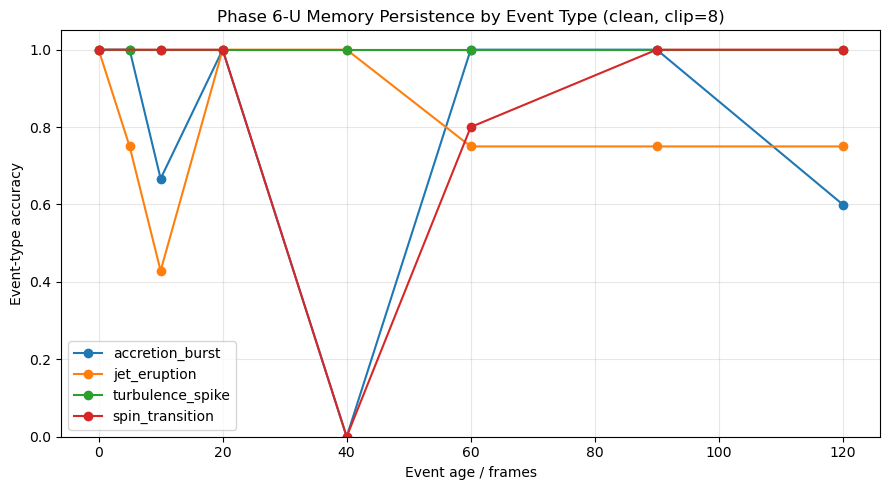

,accretion_burst,jet_eruption,turbulence_spike,spin_transition
accretion_burst,22,4,0,0
jet_eruption,1,26,0,7
turbulence_spike,0,0,29,0
spin_transition,0,6,0,17


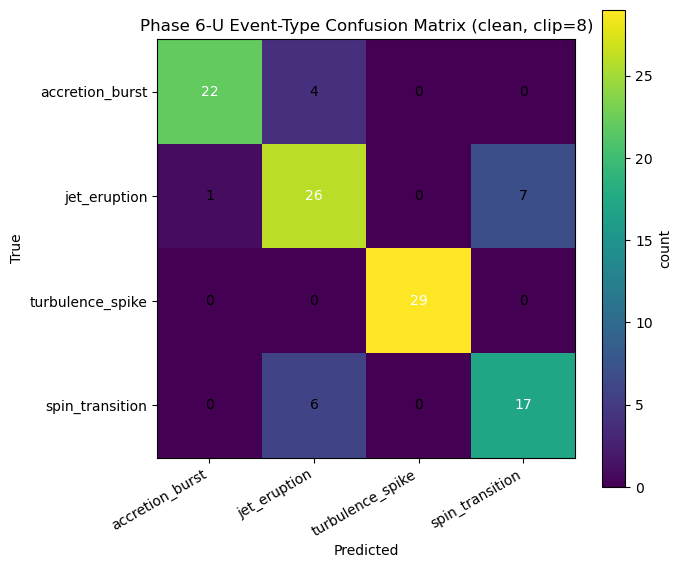

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_per_event_memory_curves_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_per_event_memory_curves_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_event_confusion_matrix_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6U_event_confusion_matrix_clean_clip8.png


In [16]:
# ================================================================
# 16. Per-event curves and confusion matrix
# ================================================================

per_event_rows = []
for event_type in EVENT_TYPES:
    for age in sorted(pred_df["event_age"].unique()):
        subset = pred_df[(pred_df["true_event_type"] == event_type) & (pred_df["event_age"] == age)]
        if len(subset):
            per_event_rows.append({
                "event_type": event_type,
                "event_age": float(age),
                "type_accuracy": float(subset["correct_type"].mean()),
                "age_mae": float(subset["age_abs_error"].mean()),
                "n": int(len(subset)),
            })

per_event_df = pd.DataFrame(per_event_rows)
per_event_path = PHASE6U_DIR / f"phase6U_per_event_memory_curves_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
per_event_df.to_csv(per_event_path, index=False)

plt.figure(figsize=(9, 5))
for event_type in EVENT_TYPES:
    sub = per_event_df[per_event_df["event_type"] == event_type]
    plt.plot(sub["event_age"].to_numpy(), sub["type_accuracy"].to_numpy(), marker="o", label=event_type)
plt.xlabel("Event age / frames")
plt.ylabel("Event-type accuracy")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-U Memory Persistence by Event Type ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
per_event_plot_path = PHASE6U_DIR / f"phase6U_per_event_memory_curves_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(per_event_plot_path, dpi=150)
plt.show()

conf = np.zeros((len(EVENT_TYPES), len(EVENT_TYPES)), dtype=np.int32)
for t, p in zip(pred_df["true_type_index"], pred_df["pred_type_index"]):
    conf[int(t), int(p)] += 1

conf_df = pd.DataFrame(conf, index=EVENT_TYPES, columns=EVENT_TYPES)
conf_path = PHASE6U_DIR / f"phase6U_event_confusion_matrix_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
conf_df.to_csv(conf_path)
display(conf_df)

plt.figure(figsize=(7, 6))
plt.imshow(conf, cmap="viridis")
plt.xticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES, rotation=30, ha="right")
plt.yticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Phase 6-U Event-Type Confusion Matrix ({INPUT_MODE}, clip={CLIP_LENGTH})")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        plt.text(j, i, str(conf[i, j]), ha="center", va="center", color="white" if conf[i, j] > conf.max()/2 else "black")
plt.colorbar(label="count")
plt.tight_layout()
conf_plot_path = PHASE6U_DIR / f"phase6U_event_confusion_matrix_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(conf_plot_path, dpi=150)
plt.show()

print("Saved:", per_event_path)
print("Saved:", per_event_plot_path)
print("Saved:", conf_path)
print("Saved:", conf_plot_path)

,observation,input_mode,clip_length,observation_window,type_accuracy,age_mae,age_r2,memory_half_life
0,single_final_frame_phase6,clean,1,final_frame_only,0.421875,31.779893,0.154620,60.996952
1,late_temporal_clip_phase6T,clean,8,last_frames_before_final,0.339286,37.343526,-0.018144,26.339593
2,event_centered_clip_phase6U,clean,8,centered_on_event,0.839286,35.103918,-0.040181,124.766493


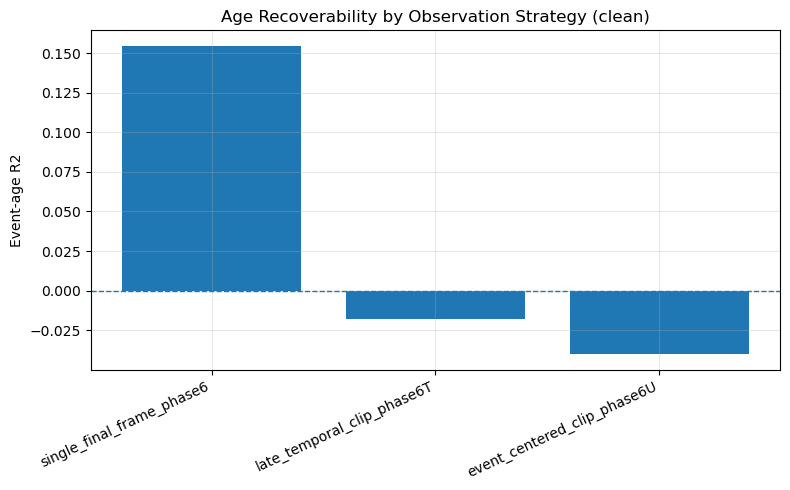

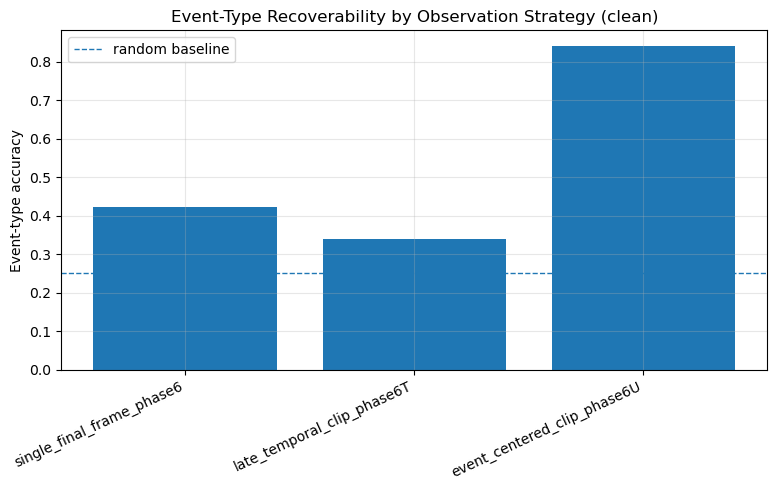

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6_phase6T_phase6U_comparison_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6_phase6T_phase6U_age_r2_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6U_event_centered_temporal_observation/phase6_phase6T_phase6U_type_accuracy_clean_clip8.png


In [17]:
# ================================================================
# 17. Compare Phase 6, Phase 6-T, and Phase 6-U
# ================================================================

comparison_rows = []

# Phase 6 static baseline.
phase6_metrics_path = PHASE6_DIR / f"phase6_test_metrics_{INPUT_MODE}.json"
phase6_half_path = PHASE6_DIR / f"phase6_memory_half_life_summary_{INPUT_MODE}.json"

if phase6_metrics_path.exists():
    with open(phase6_metrics_path, "r") as f:
        single_metrics = json.load(f)

    if phase6_half_path.exists():
        with open(phase6_half_path, "r") as f:
            single_half = json.load(f)
        single_half_life = single_half.get("memory_half_life_frames", np.nan)
    else:
        single_half_life = np.nan

    comparison_rows.append({
        "observation": "single_final_frame_phase6",
        "input_mode": INPUT_MODE,
        "clip_length": 1,
        "observation_window": "final_frame_only",
        "type_accuracy": single_metrics.get("type_accuracy", np.nan),
        "age_mae": single_metrics.get("age_mae", np.nan),
        "age_r2": single_metrics.get("age_r2", np.nan),
        "memory_half_life": single_half_life,
    })
else:
    print("Phase 6 baseline metrics not found:", phase6_metrics_path)

# Phase 6-T late temporal baseline if available.
phase6t_metrics_path = PHASE6T_DIR / f"phase6T_test_metrics_{INPUT_MODE}_clip8.json"
phase6t_half_path = PHASE6T_DIR / f"phase6T_memory_half_life_summary_{INPUT_MODE}_clip8.json"

if phase6t_metrics_path.exists():
    with open(phase6t_metrics_path, "r") as f:
        late_metrics = json.load(f)

    if phase6t_half_path.exists():
        with open(phase6t_half_path, "r") as f:
            late_half = json.load(f)
        late_half_life = late_half.get("memory_half_life_frames", np.nan)
    else:
        late_half_life = np.nan

    comparison_rows.append({
        "observation": "late_temporal_clip_phase6T",
        "input_mode": INPUT_MODE,
        "clip_length": 8,
        "observation_window": "last_frames_before_final",
        "type_accuracy": late_metrics.get("type_accuracy", np.nan),
        "age_mae": late_metrics.get("age_mae", np.nan),
        "age_r2": late_metrics.get("age_r2", np.nan),
        "memory_half_life": late_half_life,
    })
else:
    print("Phase 6-T metrics not found:", phase6t_metrics_path)

# Phase 6-U event-centered result.
comparison_rows.append({
    "observation": "event_centered_clip_phase6U",
    "input_mode": INPUT_MODE,
    "clip_length": CLIP_LENGTH,
    "observation_window": "centered_on_event",
    "type_accuracy": test_metrics["type_accuracy"],
    "age_mae": test_metrics["age_mae"],
    "age_r2": test_metrics["age_r2"],
    "memory_half_life": memory_half_life,
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_path = PHASE6U_DIR / f"phase6_phase6T_phase6U_comparison_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
comparison_df.to_csv(comparison_path, index=False)
display(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["observation"], comparison_df["age_r2"])
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.ylabel("Event-age R2")
plt.title(f"Age Recoverability by Observation Strategy ({INPUT_MODE})")
plt.xticks(rotation=25, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
comparison_plot_path = PHASE6U_DIR / f"phase6_phase6T_phase6U_age_r2_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["observation"], comparison_df["type_accuracy"])
plt.axhline(1.0 / len(EVENT_TYPES), linestyle="--", linewidth=1, label="random baseline")
plt.ylabel("Event-type accuracy")
plt.title(f"Event-Type Recoverability by Observation Strategy ({INPUT_MODE})")
plt.xticks(rotation=25, ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
type_plot_path = PHASE6U_DIR / f"phase6_phase6T_phase6U_type_accuracy_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(type_plot_path, dpi=150)
plt.show()

print("Saved:", comparison_path)
print("Saved:", comparison_plot_path)
print("Saved:", type_plot_path)

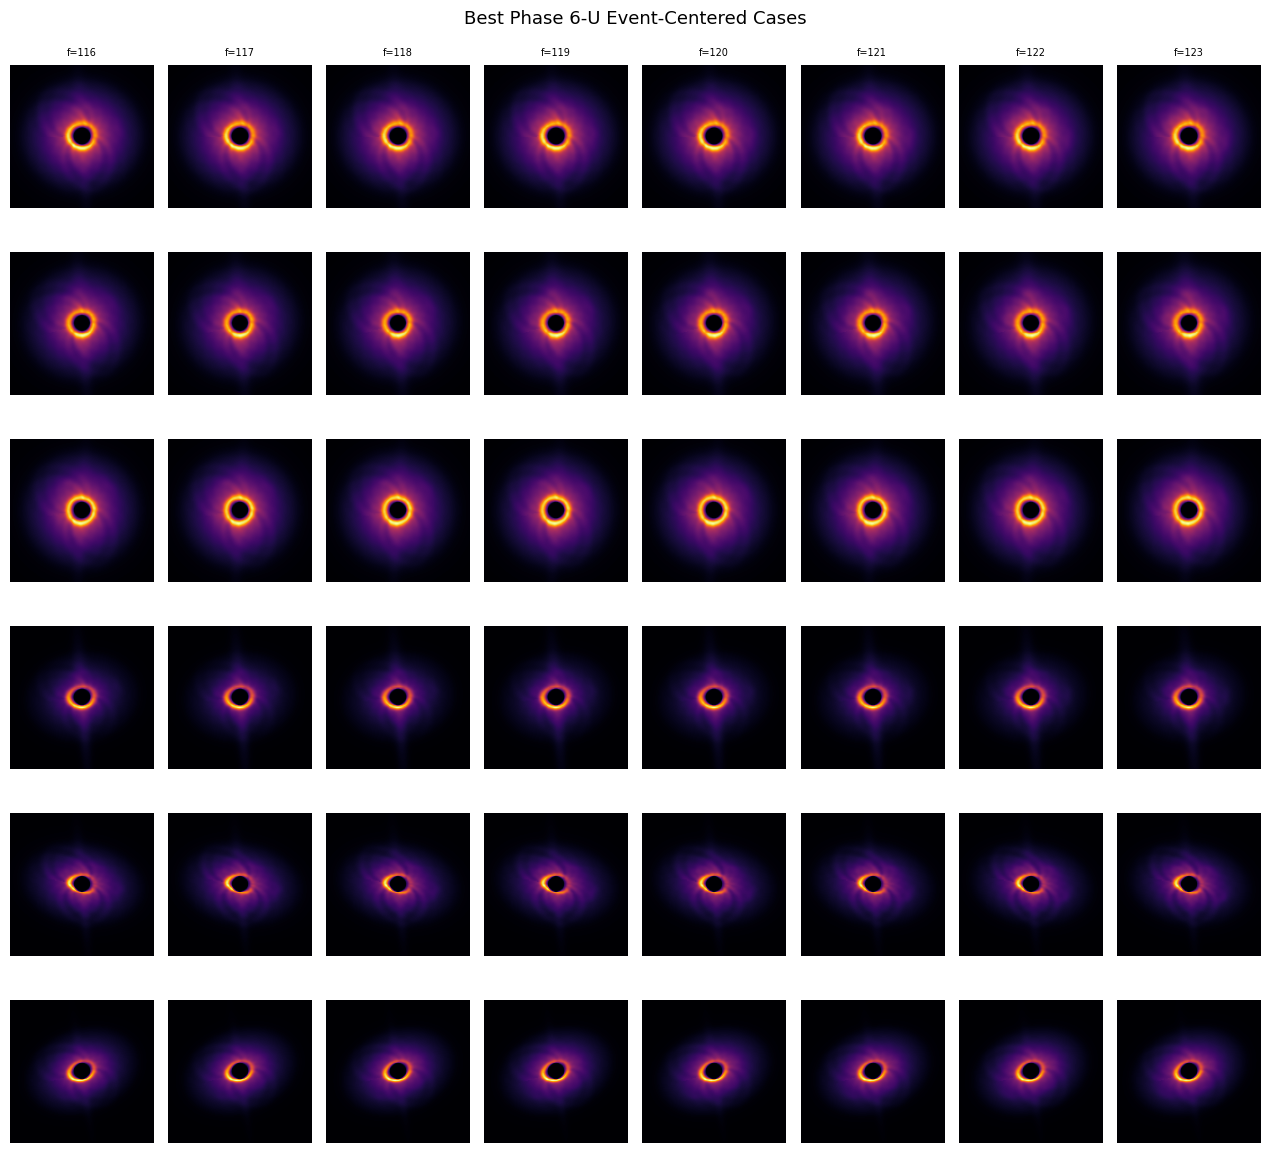

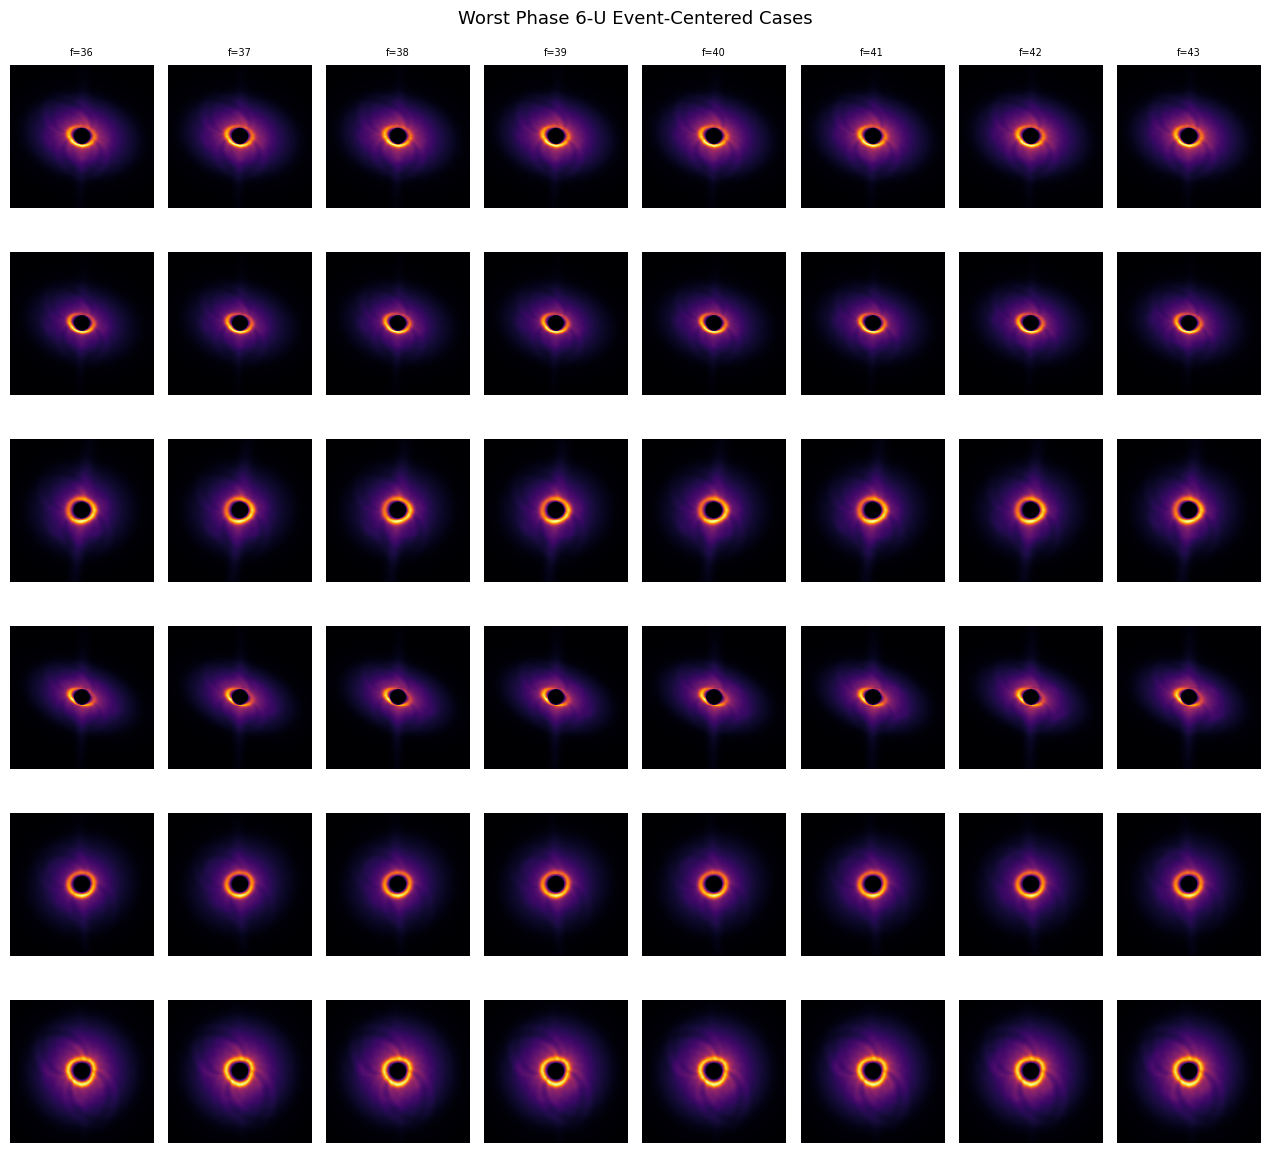


Phase 6-U Summary — Event-Centered Temporal Observation

Dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6U_event_centered_temporal_observation

Source Phase 6 dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence

Simulator source:
  /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py

Simulator SHA256:
  41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a

Input mode:
  clean

Clip length:
  8

Clip stride:
  1

Observation window:
  centered on event_center

Events:
  ['accretion_burst', 'jet_eruption', 'turbulence_spike', 'spin_transition']

Event ages:
  [0, 5, 10, 20, 40, 60, 90, 120]

Samples:
  1120

Test performance:
  Event-type accuracy = 0.83929
  Event-age MAE       = 35.104 frames
  Event-age R2        = -0.04018

Estimated memory half-life:
  124.766 frames

Interpretation:
  Phase 6-U tests whether observing the event itself improves memory recovery.
  If Phase 6-U outper

In [18]:
# ================================================================
# 18. Best/worst temporal examples and final summary
# ================================================================

best_cases = pred_df.sort_values(["correct_type", "age_abs_error"], ascending=[False, True]).head(6)
worst_cases = pred_df.sort_values(["correct_type", "age_abs_error"], ascending=[True, False]).head(6)

best_worst_path = PHASE6U_DIR / f"phase6U_best_worst_cases_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
pd.concat([
    best_cases.assign(group="best"),
    worst_cases.assign(group="worst"),
]).to_csv(best_worst_path, index=False)


def clip_path_for_case(sample_id, input_mode):
    if input_mode == "clean":
        return DATASET_DIR / "clips_clean" / f"{sample_id}.npz"
    if input_mode == "noisy":
        return DATASET_DIR / "clips_noisy" / f"{sample_id}_noisy.npz"
    raise ValueError(input_mode)


def show_temporal_cases(case_df, title, n=6):
    case_df = case_df.head(n).copy()
    if len(case_df) == 0:
        print("No cases to show.")
        return

    fig, axes = plt.subplots(len(case_df), CLIP_LENGTH, figsize=(1.6 * CLIP_LENGTH, 2.0 * len(case_df)))
    if len(case_df) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(case_df.iterrows()):
        sid = str(row["sample_id"])
        clip = load_npz_clip(clip_path_for_case(sid, INPUT_MODE))
        event_center = int(row["event_center"])
        frame_start = int(row["frame_start"])

        for t in range(CLIP_LENGTH):
            ax = axes[row_idx, t]
            ax.imshow(clip[t], cmap="inferno", vmin=0, vmax=1)
            ax.axis("off")
            frame_idx = frame_start + t * CLIP_STRIDE
            if t == 0:
                ax.set_ylabel(
                    f"{sid}\nT:{row['true_event_type']}\nP:{row['pred_event_type']}\nage={row['event_age']:.0f}\npred={row['pred_age']:.1f}",
                    fontsize=7,
                )
            if row_idx == 0:
                ax.set_title(f"f={frame_idx}", fontsize=7)
            if frame_idx == event_center:
                ax.set_xlabel("event", fontsize=7)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_temporal_cases(best_cases, "Best Phase 6-U Event-Centered Cases")
show_temporal_cases(worst_cases, "Worst Phase 6-U Event-Centered Cases")

summary_text = f"""
Phase 6-U Summary — Event-Centered Temporal Observation
=======================================================

Dataset:
  {DATASET_DIR}

Source Phase 6 dataset:
  {PHASE6_DATASET_DIR}

Simulator source:
  {GPU_SIMULATOR_PATH}

Simulator SHA256:
  {simulator_sha256}

Input mode:
  {INPUT_MODE}

Clip length:
  {CLIP_LENGTH}

Clip stride:
  {CLIP_STRIDE}

Observation window:
  centered on event_center

Events:
  {EVENT_TYPES}

Event ages:
  {EVENT_AGES}

Samples:
  {len(phase6u_params_df)}

Test performance:
  Event-type accuracy = {test_metrics['type_accuracy']:.5f}
  Event-age MAE       = {test_metrics['age_mae']:.3f} frames
  Event-age R2        = {test_metrics['age_r2']:.5f}

Estimated memory half-life:
  {memory_half_life:.3f} frames

Interpretation:
  Phase 6-U tests whether observing the event itself improves memory recovery.
  If Phase 6-U outperforms Phase 6 and Phase 6-T, then the bottleneck is not
  simply model capacity. It is observation timing: final-frame and late-time
  windows miss information that is present during the event.

Recommended next step:
  Run Phase 6-U with INPUT_MODE='noisy'. Then compare clean vs noisy and report
  Phase 6, Phase 6-T, and Phase 6-U in one final observational-regime table.
"""

summary_path = PHASE6U_DIR / f"phase6U_summary_{INPUT_MODE}_clip{CLIP_LENGTH}.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", best_worst_path)
print("Saved:", summary_path)

# Final conclusion

Phase 6-U completes the key observational-regime triad:

1. **Phase 6** — single final frame.
2. **Phase 6-T** — late-time temporal clip.
3. **Phase 6-U** — event-centered temporal clip.

This lets you test whether memory recovery depends on **what is observed**, not only on model strength.

The strongest paper-level comparison is:

```text
single final frame vs late temporal clip vs event-centered temporal clip
```

for:

- event-type accuracy
- event-age R²
- event-age MAE
- memory half-life

If Phase 6-U wins, the central conclusion becomes:

> Black-hole memory is not equally available to all observation strategies; it is strongly controlled by temporal alignment between the observation window and the physical event.